In [ ]:
# --- path bootstrap: make `src` importable and repo-relative paths resolve ---
# This notebook lives in experiments/notebooks/; run this cell first.
import os, sys
from pathlib import Path

PROJECT_ROOT = Path("/root/Hessian-Approximation-for-Toy-Models")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)  # restore repo root as cwd for relative data/figure paths


# Top-k eigenvector alignment: reference curvature vs approximators

Companion to `grad_vs_frobenius.ipynb`. Instead of measuring how an
approximator's *residual* `D = H - H_approx` lines up with the gradient
subspace, here we ask a more direct question:

> Do the **top-k eigenvector directions** of each approximator match the
> top-k eigenvector directions of the reference curvature matrix?

The reference is a hyperparameter: the **exact Hessian** or the **GNH**
(Gauss-Newton / Fisher). For two orthonormal bases `U` (top-k eigvecs of the
reference) and `W` (top-k eigvecs of an approximator) we use the
principal-angle subspace overlap

$$\mathrm{overlap}(U, W) = \frac{\lVert U^\top W\rVert_F^2}{k}
  = \frac{1}{k}\sum_{i=1}^k \cos^2\theta_i \in [0, 1],$$

where the $\theta_i$ are the principal angles between the two subspaces
(the $\cos\theta_i$ are the singular values of $U^\top W$). It is `1` iff the
subspaces coincide and `0` iff they are orthogonal. A random k-dim subspace
gives $\mathbb{E}[\mathrm{overlap}] = k / D$.

In [1]:
# Config + eigendecomposition of the reference and every approximator.
#
# Everything here works off the saved dense layer matrices, so no model or
# gradient sampling is needed (unlike grad_vs_frobenius.ipynb).
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from src.hessians.layer_matrix import LayerMatrix

# experiments/outputs/models/digits/resnet_mlp_0a69ab6297da
# --- where the model + its saved factors live ---------------------------------
MODEL_DIR = "/root/Hessian-Approximation-for-Toy-Models/experiments/outputs/models/digits/resnet_mlp_0a69ab6297da"
EPOCH = 10  # set None if the model has no per-epoch subdirs
COLLECTOR = "collector_mcmc_r1_s42"

_epoch_dir = Path(MODEL_DIR) / (f"epoch_{EPOCH}" if EPOCH is not None else "")
FACTORS_DIR = _epoch_dir / COLLECTOR / "factors"

REFERENCE = "gnh"  # "exact_hessian" or "gnh"
BY = "magnitude"  # rank eigenvalues by "magnitude" (|lambda|) or "algebraic" (lambda)


def load_sym(d: Path) -> np.ndarray:
    """Densify a layer matrix and symmetrize it."""
    M = np.asarray(LayerMatrix.load(d).to_dense())
    return (M + M.T) / 2


def eig_sorted(M: np.ndarray, by: str = BY):
    """Eigendecomposition of a symmetric matrix, eigvecs sorted so column 0 is
    the leading direction. `by='magnitude'` ranks by |lambda| (curvature
    strength, signed either way); `by='algebraic'` ranks by lambda."""
    w, V = np.linalg.eigh(M)
    key = np.abs(w) if by == "magnitude" else w
    order = np.argsort(key)[::-1]
    return w[order], V[:, order]


ref_dir = FACTORS_DIR / f"{REFERENCE}_layer_matrix"
w_ref, V_ref = eig_sorted(load_sym(ref_dir))
D_dim = V_ref.shape[0]

# Every other factor in the directory is treated as an approximator (so when
# REFERENCE='exact_hessian', GNH shows up as an approximator of the Hessian).
approx_dirs = sorted(
    d
    for d in FACTORS_DIR.iterdir()
    if d.is_dir() and d.name != f"{REFERENCE}_layer_matrix"
)

# Precompute the eigendecomposition of each approximator once.
approx_eig = {}
for ad in approx_dirs:
    name = ad.name.removesuffix("_layer_matrix")
    w_a, V_a = eig_sorted(load_sym(ad))
    approx_eig[name] = (w_a, V_a)

print(f"reference = {REFERENCE}   D = {D_dim}   ranking = {BY}")
print(f"approximators ({len(approx_eig)}): {', '.join(approx_eig)}")
print(f"reference top-5 eigvals: {w_ref[:5]}")

INFO:2026-07-05 11:12:14,158:jax._src.xla_bridge:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


INFO:2026-07-05 11:12:14,%f:xla_bridge.py:backends:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
reference = gnh   D = 2720   ranking = magnitude
approximators (12): block_fim, block_hessian, eidentity, ekfac, emac, eshampoo, exact_hessian, fim, identity, kfac, mac, shampoo
reference top-5 eigvals: [11.92790637  9.67940955  8.89478118  6.69049148  4.72897096]


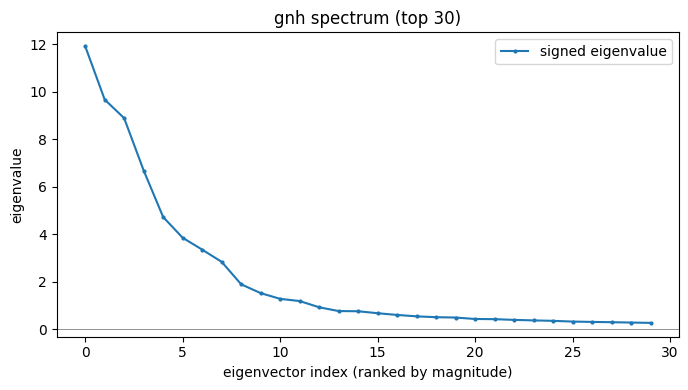

In [2]:
# Reference spectrum (analog of the scree plot) so we can see how many
# eigenvectors are well-separated / worth aligning to.
K_PLOT = 30

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(w_ref[:K_PLOT], ".-", ms=4, label="signed eigenvalue")
ax.axhline(0, color="grey", lw=0.6)
ax.set(
    xlabel="eigenvector index (ranked by %s)" % BY,
    ylabel="eigenvalue",
    title=f"{REFERENCE} spectrum (top {K_PLOT})",
)
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
# Helper: leading-block correlation between reference and approximator eigvecs.
#
# C = V_ref[:, :N]^T @ V_approx[:, :N]   (N x N), C[i, j] = <ref_i, approx_j>.
# The top-left k x k block holds all inner products among the top-k of each.
# Subspace overlap at dimension k is  ||C[:k, :k]||_F^2 / k, which we read off
# an integral image of C**2 in O(N^2) for every k at once.
N_MAX = min(200, D_dim)
N_MAX = D_dim


def overlap_curve(V_approx: np.ndarray, n_max: int = N_MAX) -> np.ndarray:
    """overlap(k) = ||C[:k,:k]||_F^2 / k for k = 1..n_max."""
    C = V_ref[:, :n_max].T @ V_approx[:, :n_max]  # (n_max, n_max)
    block = (C**2).cumsum(0).cumsum(1)  # integral image
    diag = np.diagonal(block)  # block[k-1, k-1] = ||C[:k,:k]||_F^2
    return diag / np.arange(1, n_max + 1)


overlap = {nm: overlap_curve(V_a) for nm, (w_a, V_a) in approx_eig.items()}
print(f"computed overlap curves up to k = {N_MAX}")

computed overlap curves up to k = 2720


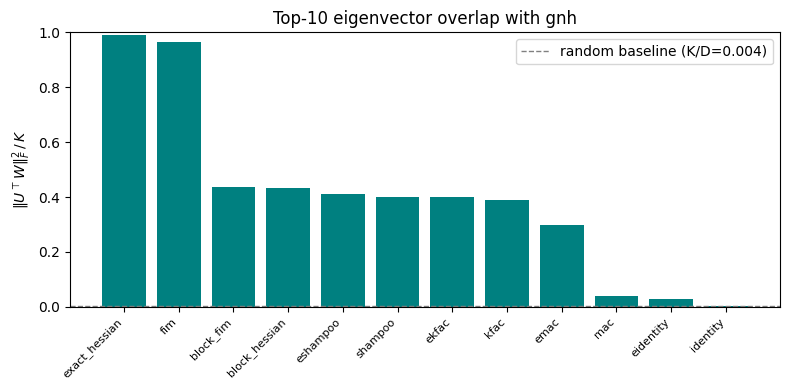

exact_hessian                   overlap@10 = 0.9918   (x baseline = 269.8)
fim                             overlap@10 = 0.9662   (x baseline = 262.8)
block_fim                       overlap@10 = 0.4358   (x baseline = 118.5)
block_hessian                   overlap@10 = 0.4322   (x baseline = 117.6)
eshampoo                        overlap@10 = 0.4096   (x baseline = 111.4)
shampoo                         overlap@10 = 0.4009   (x baseline = 109.1)
ekfac                           overlap@10 = 0.3987   (x baseline = 108.5)
kfac                            overlap@10 = 0.3899   (x baseline = 106.0)
emac                            overlap@10 = 0.2989   (x baseline = 81.3)
mac                             overlap@10 = 0.0406   (x baseline = 11.1)
eidentity                       overlap@10 = 0.0280   (x baseline = 7.6)
identity                        overlap@10 = 0.0014   (x baseline = 0.4)


In [4]:
# Bar chart: top-K eigenvector subspace overlap per approximator.
# Bars near 1 => the approximator's leading curvature directions match the
# reference. The dashed line is the random k-dim subspace expectation k/D.
K = 10

names = list(overlap)
vals = [overlap[nm][K - 1] for nm in names]
order = np.argsort(vals)[::-1]
names = [names[i] for i in order]
vals = [vals[i] for i in order]
baseline = K / D_dim

fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(names)), 4))
ax.bar(range(len(names)), vals, color="teal")
ax.axhline(
    baseline, ls="--", color="grey", lw=1, label=f"random baseline (K/D={baseline:.3f})"
)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_ylim(0, 1)
ax.set_ylabel(r"$\|U^\top W\|_F^2 \, / \, K$")
ax.set_title(f"Top-{K} eigenvector overlap with {REFERENCE}")
ax.legend()
plt.tight_layout()
plt.show()

for nm, v in zip(names, vals):
    print(f"{nm:30s}  overlap@{K} = {v:.4f}   (x baseline = {v / baseline:.1f})")

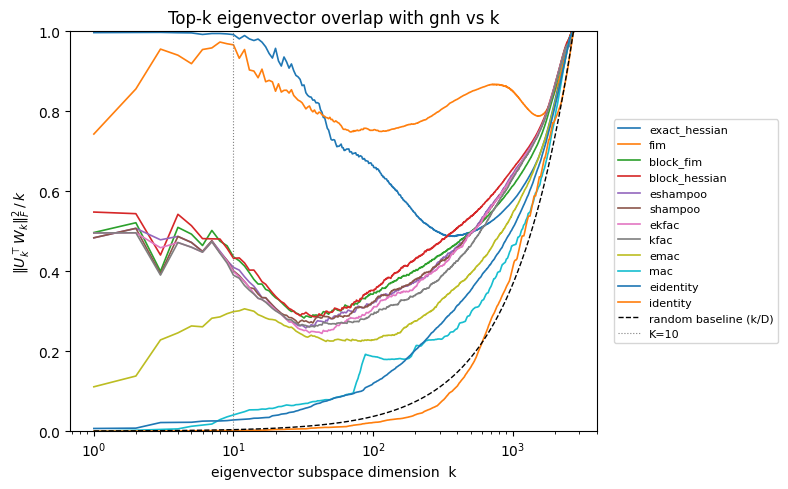

In [5]:
# Overlap as a function of the subspace dimension k.
# Curves above the dashed diagonal k/D mean the leading eigenvectors are
# preferentially aligned with the reference; overlap=1 means identical subspace.
fig, ax = plt.subplots(figsize=(8, 5))
ks = np.arange(1, N_MAX + 1)
for nm in sorted(overlap, key=lambda n: overlap[n][min(K, N_MAX) - 1], reverse=True):
    ax.plot(ks, overlap[nm], "-", lw=1.2, label=nm)

ax.plot(ks, ks / D_dim, "k--", lw=1, label="random baseline (k/D)")
ax.axvline(K, ls=":", color="grey", lw=0.8, label=f"K={K}")
ax.set_xlabel("eigenvector subspace dimension  k")
ax.set_ylabel(r"$\|U_k^\top W_k\|_F^2 \, / \, k$")
ax.set_ylim(0, 1)
ax.set_xscale("log")
ax.set_title(f"Top-k eigenvector overlap with {REFERENCE} vs k")
ax.legend(fontsize=8, ncol=1, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

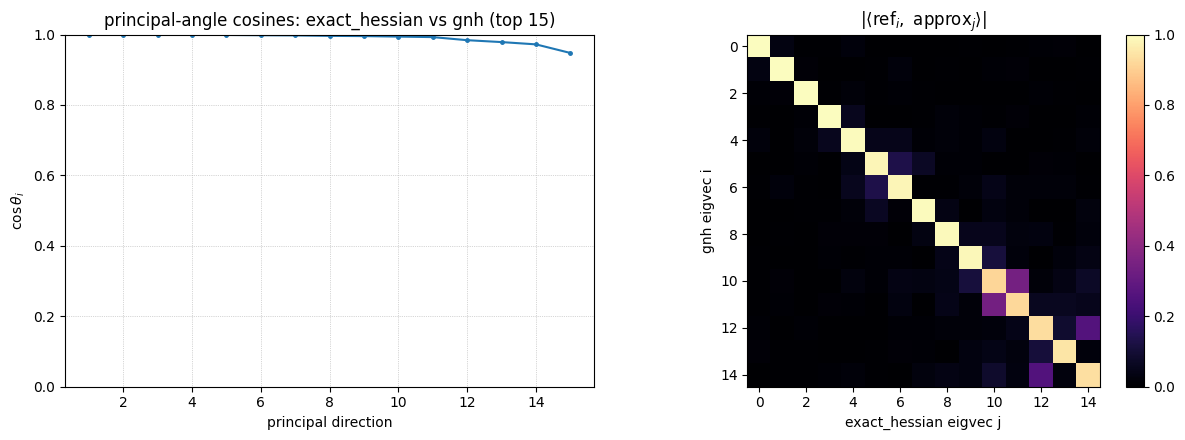

mean cos(theta) over top 15: 0.990
top-1 eigenvector alignment |<ref_1, approx_1>|: 0.998


In [6]:
# Per-direction detail for a chosen approximator: principal-angle cosines
# (singular values of U_K^T W_K) and the raw |<ref_i, approx_j>| correlation
# heatmap. A near-diagonal heatmap with strong cosines means the eigenvectors
# match one-for-one and in the same order; off-diagonal mass means the leading
# subspace is shared but the directions are rotated/reordered within it.
WHICH = max(overlap, key=lambda n: overlap[n][min(K, N_MAX) - 1])  # best approximator
K_DETAIL = 15

w_a, V_a = approx_eig[WHICH]
C = V_ref[:, :K_DETAIL].T @ V_a[:, :K_DETAIL]
cos_angles = np.linalg.svd(C, compute_uv=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(np.arange(1, K_DETAIL + 1), cos_angles, ".-", ms=5)
axes[0].set_ylim(0, 1)
axes[0].set(
    xlabel="principal direction",
    ylabel=r"$\cos\theta_i$",
    title=f"principal-angle cosines: {WHICH} vs {REFERENCE} (top {K_DETAIL})",
)
axes[0].grid(True, ls=":", lw=0.5)

im = axes[1].imshow(np.abs(C), cmap="magma", vmin=0, vmax=1)
axes[1].set(
    xlabel=f"{WHICH} eigvec j",
    ylabel=f"{REFERENCE} eigvec i",
    title=r"$|\langle \mathrm{ref}_i,\ \mathrm{approx}_j\rangle|$",
)
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

print(f"mean cos(theta) over top {K_DETAIL}: {cos_angles.mean():.3f}")
print(f"top-1 eigenvector alignment |<ref_1, approx_1>|: {abs(C[0, 0]):.3f}")

## Singular subspaces of `M` restricted to the gradient subspace

During training the loss only really moves along the **gradient distribution** —
a low-dimensional subspace $V_\mathrm{grad}\subset V$ (cf. `grad_vs_frobenius.ipynb`),
with orthonormal basis = columns of $P\in\mathbb{R}^{D\times m}$ ($m=\dim V_\mathrm{grad}$).

Restricting an operator to it gives
$$N = M|_{V_\mathrm{grad}} = M P\;:\;V_\mathrm{grad}\to V,$$
a map **between different spaces** — its image $M(V_\mathrm{grad})$ generally
leaves $V_\mathrm{grad}$. So $N$ is *not* an endomorphism and has **no
eigenvalues**; the right object is its **SVD** $N\,w_i = \sigma_i\,u_i$
($\sigma_1\ge\sigma_2\ge\cdots\ge 0$), giving two singular bases:

| | vectors | live in |
|---|---|---|
| **domain** | $w_i$ (right sing. vec.) | $V_\mathrm{grad}$ — *shared* |
| **image** | $u_i$ (left sing. vec.) | $M(V_\mathrm{grad})$ — *per-operator* |

We compare the **top-$k$ subspaces** of the reference and an approximator with
the principal-angle overlap (not an index-by-index dot product, which is fragile
to near-degenerate $\sigma_i$ rotating the vectors within a block):

$$\mathrm{overlap}(k) = \frac{\lVert A_{:k}^\top B_{:k}\rVert_F^2}{k}
  = \frac1k\sum_{i\le k}\cos^2\theta_i \in [0,1].$$

- **domain** ($A=W_\mathrm{ref}, B=W$): which directions of $V_\mathrm{grad}$ each
  operator stretches most. Trivially $1$ at $k=m$ (both span $V_\mathrm{grad}$);
  the *climb* for $k<m$ is the signal. Random baseline $k/m$.
- **image** ($A=U_\mathrm{ref}, B=U$): where each operator *sends* those
  directions. Informative all the way to $k=m$, where it is the overlap of the
  full image subspaces $M(V_\mathrm{grad})$ vs $M'(V_\mathrm{grad})$. Random
  baseline $k/D$.

(Read dips against the singular-value spectrum: tail directions with small
$\sigma_i$ are noisy.)

In [7]:
# Sample per-sample gradients (same path as grad_vs_frobenius.ipynb).
# This is the only cell that needs the model + a GPU; everything above is pure
# numpy on the saved matrices. MODEL_DIR / EPOCH come from the first config cell.
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "7"  # pick the GPU you want
import jax

print(jax.devices())

from src.config import VectorAnalysisConfig, VectorSamplingMethod
from src.hessians.utils.pseudo_targets import sample_vectors
from src.utils.loss import get_loss
from src.utils.train import load_model_checkpoint, load_train_test_for_model

N_GRADS = 1000
ANALYSIS_SEED = 42
USE_SPLIT = "train"  # "train" or "test"

params, model, model_config, metadata = load_model_checkpoint(MODEL_DIR, epoch=EPOCH)
train_ds, test_ds = load_train_test_for_model(MODEL_DIR)
ds = train_ds if USE_SPLIT == "train" else test_ds
loss_fn = get_loss(model_config.loss)

vector_cfg = VectorAnalysisConfig(
    num_samples=N_GRADS,
    sampling_method=VectorSamplingMethod.GRADIENTS,
)
G = sample_vectors(
    vector_cfg,
    model=model,
    params=params,
    inputs=ds.inputs,
    targets=ds.targets,
    loss_fn=loss_fn,
    analysis_seed=ANALYSIS_SEED,
)
G = np.asarray(G)
assert G.shape[1] == D_dim, (G.shape, D_dim)
print(f"gradient matrix: {G.shape}   ({G.nbytes / 1e6:.1f} MB)")

[CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3), CudaDevice(id=4), CudaDevice(id=5), CudaDevice(id=6), CudaDevice(id=7)]
gradient matrix: (1000, 2720)   (10.9 MB)


In [8]:
# Gradient subspace: top-M_SUB PCA directions (orthonormal columns in param
# space). Following grad_vs_frobenius.ipynb the gradients are NOT centered.
G_centered = G
sv = np.linalg.svd(G_centered, compute_uv=False)
g_eigvals = sv**2 / G.shape[0]
explained = g_eigvals / g_eigvals.sum()
eff_rank = int(round(1.0 / np.sum(explained**2)))

_, _, Vt_g = np.linalg.svd(G_centered, full_matrices=False)

# Restrict onto the gradient subspace itself = its (participation-ratio)
# effective rank. Bump this up by hand to probe directions beyond where the
# gradients actually live.
M_SUB = eff_rank
V_grad = Vt_g[:M_SUB].T  # (D_dim, M_SUB), orthonormal columns
assert V_grad.shape == (D_dim, M_SUB)
print(
    f"gradient effective rank ~ {eff_rank}   |   restricting onto M_SUB = {M_SUB} dims"
)
print(f"top-5 gradient-PCA eigenvalues: {g_eigvals[:5]}")

gradient effective rank ~ 12   |   restricting onto M_SUB = 12 dims
top-5 gradient-PCA eigenvalues: [8.228674  7.3338985 5.140384  4.12068   3.309516 ]


In [9]:
# N = M|_V_grad = M @ V_grad : V_grad -> V is a between-spaces map, so it has an
# SVD (not an eigendecomposition): N w_i = sigma_i u_i. We keep both singular
# bases: right vectors w_i (inputs, in V_grad) and left vectors u_i (images, in
# M(V_grad)), sorted by singular value, then compare TOP-k SUBSPACES.
m = M_SUB


def svd_restrict(M: np.ndarray):
    """SVD of N = M|_V_grad = M P. Returns
    sigma : singular values (desc),
    U     : left  sing. vectors u_i (images)  in ambient R^D,    (D, m),
    W     : right sing. vectors w_i (inputs)  in V_grad coords,  (m, m) columns.
    """
    N = M @ V_grad  # (D, m) = M P
    U, s, Wt = np.linalg.svd(N, full_matrices=False)
    return s, U, Wt.T  # columns of Wt.T are w_i in V_grad coordinates


def subspace_overlap_curve(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """overlap(k) = ||A[:, :k]^T B[:, :k]||_F^2 / k for k = 1..m, via an integral
    image of (A^T B)**2. A, B have orthonormal columns (same count m)."""
    C = A.T @ B  # (m, m)
    blk = (C**2).cumsum(0).cumsum(1)
    return np.diagonal(blk) / np.arange(1, C.shape[1] + 1)


s_ref, U_ref, W_ref = svd_restrict(load_sym(ref_dir))
sub_svd = {
    nm: svd_restrict(load_sym(FACTORS_DIR / f"{nm}_layer_matrix")) for nm in approx_eig
}
assert U_ref.shape == (D_dim, m) and W_ref.shape == (m, m)

# Top-k principal-angle subspace overlap of each singular basis vs the reference.
overlap_dom = {
    nm: subspace_overlap_curve(W_ref, W_a) for nm, (s_a, U_a, W_a) in sub_svd.items()
}
overlap_img = {
    nm: subspace_overlap_curve(U_ref, U_a) for nm, (s_a, U_a, W_a) in sub_svd.items()
}
ks = np.arange(1, m + 1)
base_dom = ks / m  # random k-subspace inside V_grad (R^m)
base_img = ks / D_dim  # random k-subspace in R^D
print(f"m = {m}   subspace-overlap curves computed (domain in R^m, image in R^D)")
print(f"reference top-5 singular values: {s_ref[:5]}")

m = 12   subspace-overlap curves computed (domain in R^m, image in R^D)
reference top-5 singular values: [11.72245131  9.48467253  8.70429877  6.46469247  4.45190606]


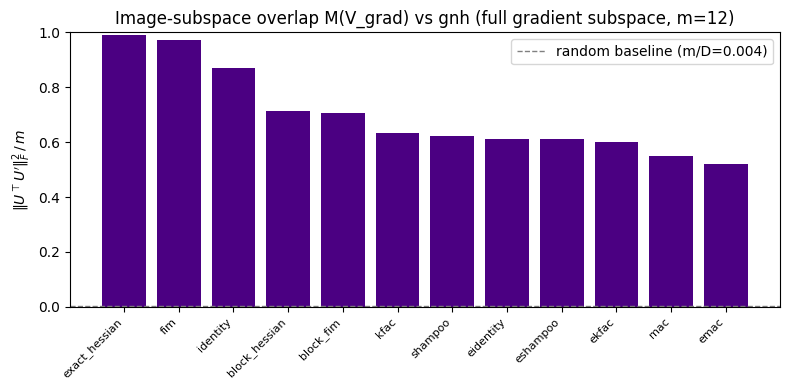

exact_hessian                   image overlap@m = 0.9903   (x baseline = 224.5)
fim                             image overlap@m = 0.9719   (x baseline = 220.3)
identity                        image overlap@m = 0.8697   (x baseline = 197.1)
block_hessian                   image overlap@m = 0.7150   (x baseline = 162.1)
block_fim                       image overlap@m = 0.7052   (x baseline = 159.9)
kfac                            image overlap@m = 0.6317   (x baseline = 143.2)
shampoo                         image overlap@m = 0.6225   (x baseline = 141.1)
eidentity                       image overlap@m = 0.6115   (x baseline = 138.6)
eshampoo                        image overlap@m = 0.6104   (x baseline = 138.4)
ekfac                           image overlap@m = 0.6002   (x baseline = 136.0)
mac                             image overlap@m = 0.5495   (x baseline = 124.6)
emac                            image overlap@m = 0.5216   (x baseline = 118.2)


In [10]:
# Bar chart: full image-subspace overlap at k=m, i.e. how much each operator's
# image of the gradient subspace, M(V_grad), coincides with the reference's.
# (Domain at k=m is trivially 1 -- both span V_grad -- so the headline scalar is
# the image side; see the curves cell for the domain climb at k<m.)
vals_img = {nm: overlap_img[nm][-1] for nm in overlap_img}  # k = m
names = sorted(vals_img, key=vals_img.get, reverse=True)
vals = [vals_img[nm] for nm in names]
baseline = m / D_dim

fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(names)), 4))
ax.bar(range(len(names)), vals, color="indigo")
ax.axhline(
    baseline, ls="--", color="grey", lw=1, label=f"random baseline (m/D={baseline:.3f})"
)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.set_ylim(0, 1)
ax.set_ylabel(r"$\|U^\top U'\|_F^2 \, / \, m$")
ax.set_title(
    f"Image-subspace overlap M(V_grad) vs {REFERENCE} (full gradient subspace, m={m})"
)
ax.legend()
plt.tight_layout()
plt.show()

for nm, v in zip(names, vals):
    print(f"{nm:30s}  image overlap@m = {v:.4f}   (x baseline = {v / baseline:.1f})")

INFO:2026-07-05 11:12:54,%f:_mathtext.py:_get_glyph:638: Substituting symbol R from STIXGeneral


INFO:2026-07-05 11:12:54,%f:_mathtext.py:_get_glyph:638: Substituting symbol R from STIXGeneral


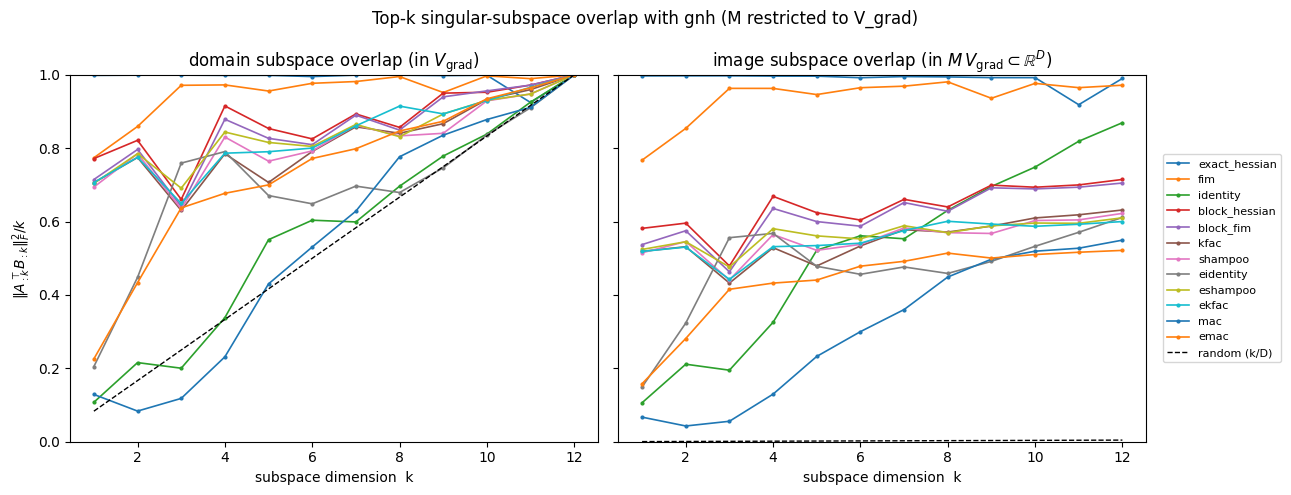

In [11]:
# Top-k subspace overlap, domain (left) and image (right). With m > 1 these are
# curves vs k; with m == 1 there is only k=1, so a curve is a single point and we
# draw bars per approximator instead.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ordering = sorted(overlap_img, key=lambda n: overlap_img[n][-1], reverse=True)

if m == 1:
    xpos = np.arange(len(ordering))
    axes[0].bar(xpos, [overlap_dom[nm][0] for nm in ordering], color="teal")
    axes[1].bar(xpos, [overlap_img[nm][0] for nm in ordering], color="indigo")
    axes[0].axhline(base_dom[0], ls="--", color="k", lw=1, label="random (1/m)")
    axes[1].axhline(base_img[0], ls="--", color="k", lw=1, label="random (1/D)")
    for ax in axes:
        ax.set_xticks(xpos)
        ax.set_xticklabels(ordering, rotation=45, ha="right", fontsize=8)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
    axes[0].set_ylabel(r"overlap at $k=1$  ($|\langle a_1, a_1'\rangle|^2$)")
else:
    for nm in ordering:
        axes[0].plot(ks, overlap_dom[nm], ".-", lw=1.2, ms=4, label=nm)
        axes[1].plot(ks, overlap_img[nm], ".-", lw=1.2, ms=4, label=nm)
    axes[0].plot(ks, base_dom, "k--", lw=1, label="random (k/m)")
    axes[1].plot(ks, base_img, "k--", lw=1, label="random (k/D)")
    for ax in axes:
        ax.set_xlabel("subspace dimension  k")
        ax.set_ylim(0, 1)
    axes[0].set_ylabel(r"$\|A_{:k}^\top B_{:k}\|_F^2 / k$")
    axes[1].legend(fontsize=8, ncol=1, loc="center left", bbox_to_anchor=(1.02, 0.5))

axes[0].set_title(r"domain subspace overlap (in $V_\mathrm{grad}$)")
axes[1].set_title(
    r"image subspace overlap (in $M\,V_\mathrm{grad}\subset\mathbb{R}^D$)"
)
fig.suptitle(
    f"Top-k singular-subspace overlap with {REFERENCE} (M restricted to V_grad)"
)
plt.tight_layout()
plt.show()